### Vizualizations for Experiment 06 and 08.

- bin by ground truth likelihoods and by absolute deltas
- correlate exp06 and exp06-llama
- correlate exp06 and exp08
- correlate exp06/exp08 with success metrics

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
save_freq = 10
timings_qwen = { # approximate
    "qwen2.5_7b__grpo" : 1000 * save_freq,
    "qwen2.5_7b__kl-cov" : 1400 * save_freq,
    "qwen2.5_7b__dapo" : 2200 * save_freq,
    "qwen2.5_7b__grpo-s" : 1100 * save_freq
}
qwen_path = "/ptmp/rfechner/out/exp08"
qwen_methods = os.listdir(qwen_path)
qwen_rs_paths = list(filter(lambda x: x.startswith('reasoning_strategies'), qwen_methods))
qwen_rt_paths = list(filter(lambda x: x.startswith('reasoning_types'), qwen_methods))
qwen_es_paths = list(filter(lambda x: x.startswith('error_types'), qwen_methods))
qwen_es_paths_abs = [os.path.join(qwen_path, r) for r in qwen_es_paths]
qwen_rs_paths_abs = [os.path.join(qwen_path, r) for r in qwen_rs_paths]
qwen_rt_paths_abs = [os.path.join(qwen_path, r) for r in qwen_rt_paths]

In [3]:
from typing import Tuple
parameters = {
    'High $\\log p(gt)$, Low $\\Delta$' : {"ground_truth_t" : -1, "delta_t" : 1},
    'High $\\log p(gt)$, All $\\Delta$' : {"ground_truth_t" : -1, "delta_t" : np.inf},
    'All $\\log p(gt)$, Low $\\Delta$' : {"ground_truth_t" : -np.inf, "delta_t" : 1},
    'All $\\log p(gt)$, All $\\Delta$' : {"ground_truth_t" : -np.inf, "delta_t" : np.inf}
}

def load(paths: list[str], ground_truth_t = -np.inf, delta_t = 1000) -> Tuple[dict, float]:
    per_methods = {}
    drop_pp = []
    for path in paths:
        assert os.path.isdir(path)
        basename = os.path.basename(path)
        method = '__'.join(basename.split('__')[1:]) if '__' in basename else basename

        validation_dir_path = os.path.join(path, 'val_jsonl')
        precomp_files = [f for f in os.listdir(validation_dir_path) if f.endswith('_precomp.jsonl')]
        precomp_files = sorted(precomp_files, key=lambda x: int(x.split("_")[0]))

        checkpoints = []
        drop_p = []
        for pfile in precomp_files: # iterates over the checkpoints
            df = pd.read_json(os.path.join(validation_dir_path, pfile), lines=True)

            # Compute per-row means
            df['lpmean'] = df['logprobs'].apply(np.mean)
            df['entmean'] = df['entropy'].apply(np.mean)

            rows = []
            valid = 0
            for index, group_df in df.groupby('index'):
                # find anchor
                anchor_row = group_df[group_df['behaviour_type'] == 'anchor']
                other_rows = group_df[group_df['behaviour_type'] != 'anchor']
                lpdelta =  other_rows['lpmean'].to_numpy() - anchor_row['lpmean'].to_numpy()
                
                # filtering per checkpoint: Filter out indices which have unlikely anchor
                # or filter rows-per-index which have large delta distance to anchor
                if anchor_row['lpmean'].item() < ground_truth_t:
                    continue

                for bt, delta, behlp in zip(other_rows['behaviour_type'], lpdelta, other_rows['lpmean']):
                    if np.abs(delta) < delta_t:
                        rows.append({'behaviour_type': bt, 'lpgt': anchor_row['lpmean'].item(), 'lpdelta': delta, 'behlp' : behlp})
                        valid += 1
                    else:
                        rows.append({'behaviour_type': bt, 'lpgt': anchor_row['lpmean'].item(), 'lpdelta': np.nan, 'behlp' : behlp})
            # Create aggregated mean DataFrame
            new_df = pd.DataFrame(rows)
            checkpoints.append(new_df)
            drop_p.append(1 - valid / len(df))

        print(f'Path: {path}, Dropped {np.mean(drop_p) * 100:.2f} percent of rows on average.')
        drop_pp.append(np.mean(drop_p))
        per_methods[method] = checkpoints

    return per_methods, np.round(np.mean(drop_pp), decimals=2).item()

Path: /ptmp/rfechner/out/exp08/reasoning_strategies__qwen2.5_7b__dapo, Dropped 39.06 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/reasoning_strategies__qwen2.5_7b__grpo, Dropped 46.91 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/reasoning_strategies__qwen2.5_7b__grpo-s, Dropped 47.25 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/reasoning_strategies__qwen2.5_7b__kl-cov, Dropped 41.11 percent of rows on average.


/tmp/ipykernel_48164/1052461067.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1, 1.04))


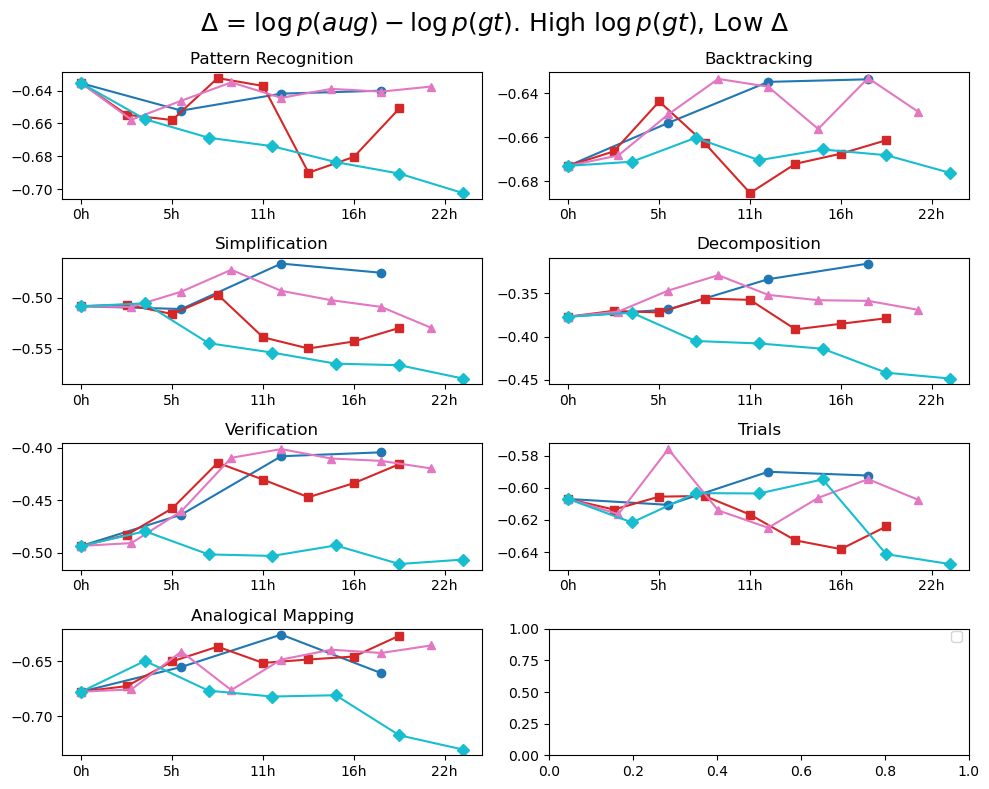

Path: /ptmp/rfechner/out/exp08/reasoning_strategies__qwen2.5_7b__dapo, Dropped 26.94 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/reasoning_strategies__qwen2.5_7b__grpo, Dropped 35.03 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/reasoning_strategies__qwen2.5_7b__grpo-s, Dropped 35.69 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/reasoning_strategies__qwen2.5_7b__kl-cov, Dropped 26.75 percent of rows on average.


/tmp/ipykernel_48164/1052461067.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1, 1.04))


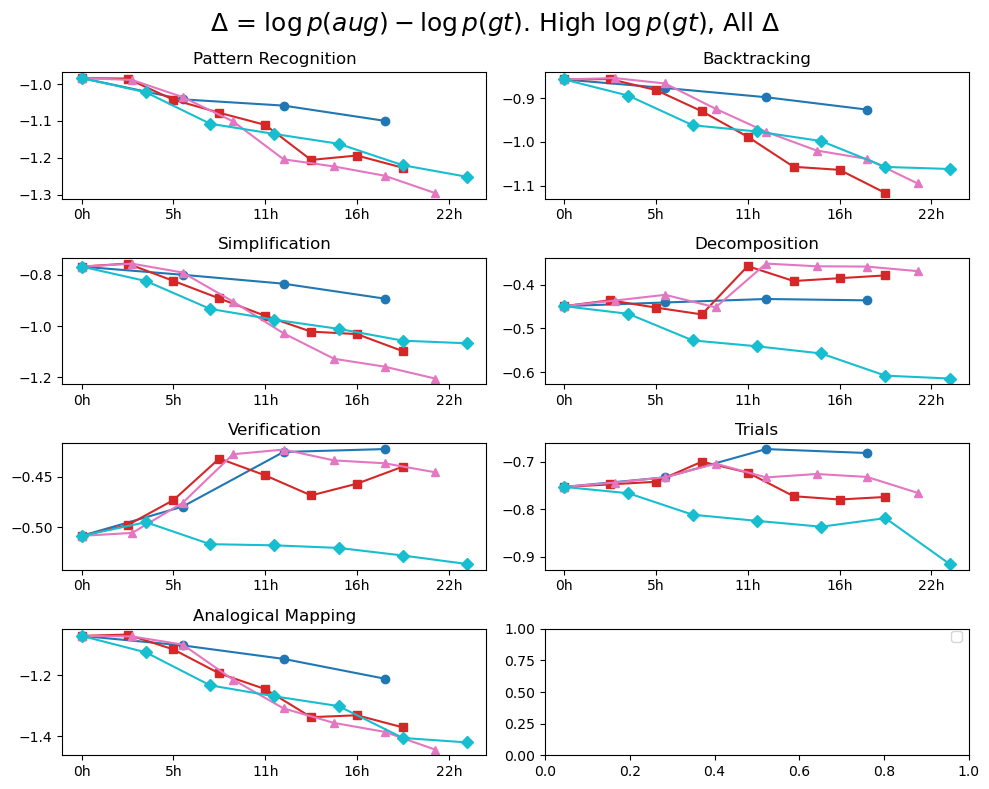

Path: /ptmp/rfechner/out/exp08/reasoning_strategies__qwen2.5_7b__dapo, Dropped 25.38 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/reasoning_strategies__qwen2.5_7b__grpo, Dropped 25.56 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/reasoning_strategies__qwen2.5_7b__grpo-s, Dropped 25.28 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/reasoning_strategies__qwen2.5_7b__kl-cov, Dropped 27.43 percent of rows on average.


/tmp/ipykernel_48164/1052461067.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1, 1.04))


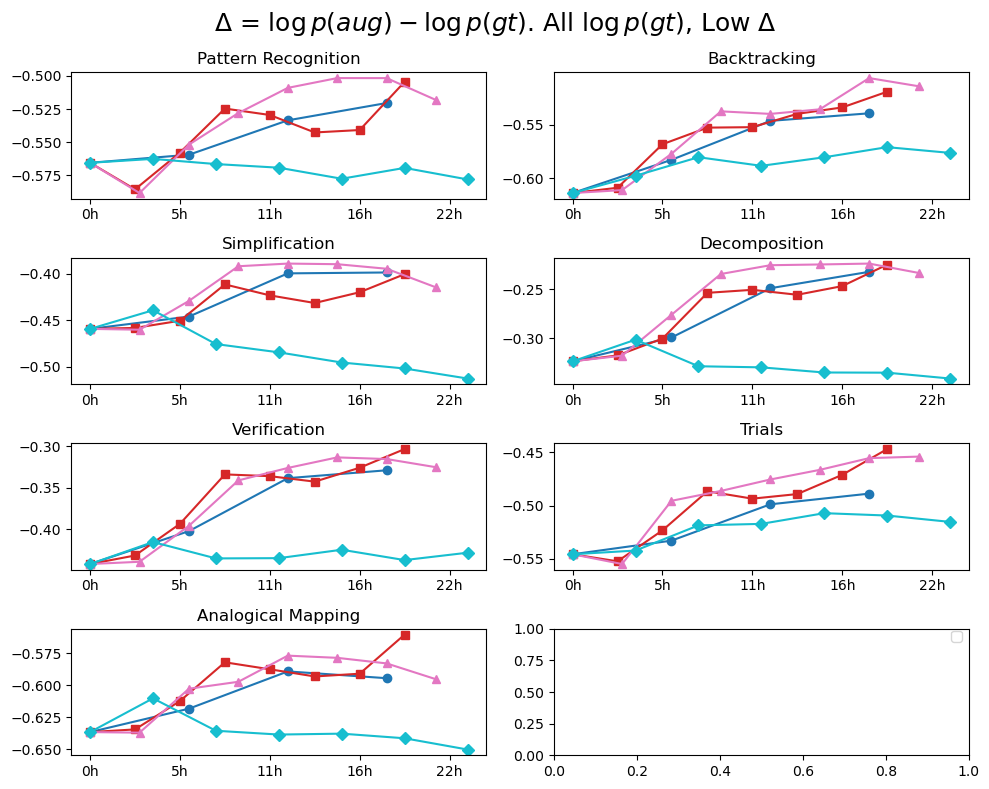

Path: /ptmp/rfechner/out/exp08/reasoning_strategies__qwen2.5_7b__dapo, Dropped 12.50 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/reasoning_strategies__qwen2.5_7b__grpo, Dropped 12.50 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/reasoning_strategies__qwen2.5_7b__grpo-s, Dropped 12.50 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/reasoning_strategies__qwen2.5_7b__kl-cov, Dropped 12.50 percent of rows on average.


/tmp/ipykernel_48164/1052461067.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1, 1.04))


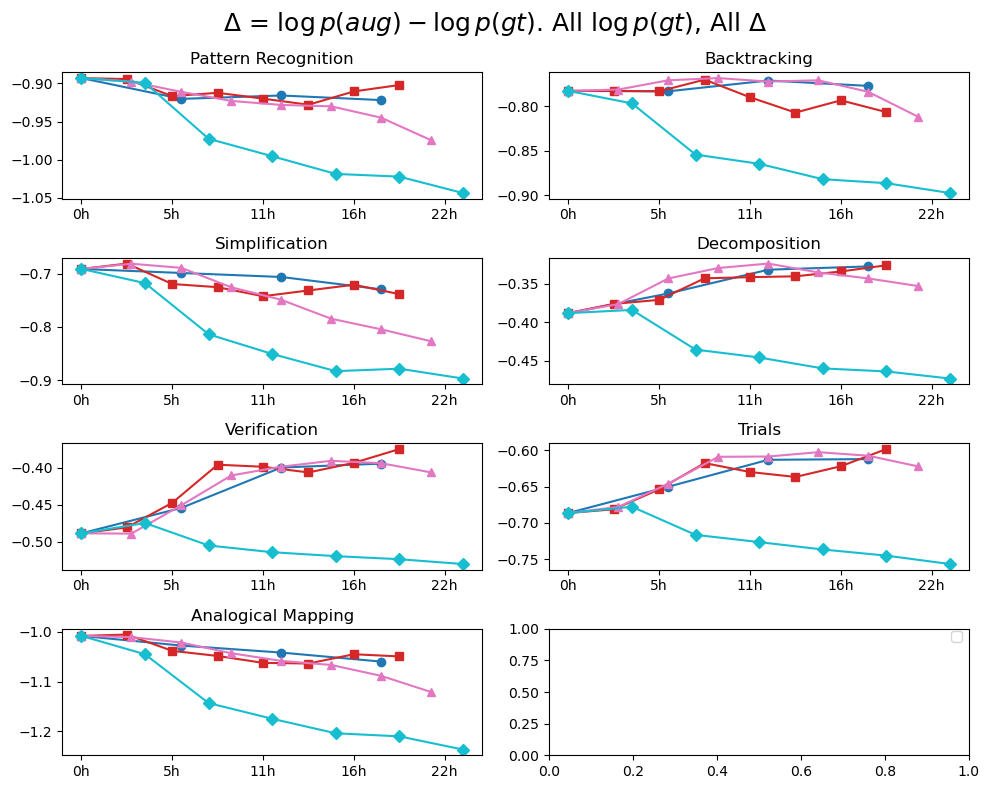

In [4]:
def plot(
    data: dict,
    behaviour_types : list[str],
    time_per_step_s: dict[str, int],
    suptitle_inject : str
):

    methods = list(data.keys())
    n_behaviours = len(behaviour_types)
    
    # -------------------------------
    # Create figure
    # -------------------------------
    ncols=int(np.sqrt(n_behaviours))
    nrows =int(np.ceil(n_behaviours / ncols))
    fig, axes = plt.subplots(
        figsize=(5 * ncols , 2 * nrows),
        ncols=ncols, nrows=nrows,
        squeeze=False
    )

    axes = axes.flatten()
    colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
    markers = ['o', 's', '^', 'D', 'x', 'v']

    behaviours = { b : {m : [] for m in methods} for b in behaviour_types}
    ground_truths = {m : [] for m in methods}
    
    # precompute plotting y-values
    for method, checkpoints_data in data.items():
        for df in checkpoints_data:
            for name, group in df.groupby('behaviour_type'):
                behaviours[name][method].append(np.nanmean(group['lpdelta']))
    
    for ax, beh in zip(axes, behaviour_types):
        for (method, values), color, marker in zip(behaviours[beh].items(), colors, markers):
            xs = np.arange(len(values)) * time_per_step_s[method]
            ax.plot(xs, values, label=method, marker=marker, color=color)
        ax.set_title(beh)

        x_seconds = np.arange(0, 90000, 20000)
        ax.set_xticks(x_seconds, [f"{int(h)}h" for h in (x_seconds // 3600)])
    
    fig.suptitle(f"$\\Delta$ = $\\log p (aug) - \\log p(gt)$. {suptitle_inject}", fontsize=18)
    plt.legend(bbox_to_anchor=(1, 1.04))
    plt.tight_layout()
    plt.show()

for name, params in parameters.items():
    data, drop_p = load(qwen_rs_paths_abs, **params)
    behaviour_types = data[list(data.keys())[0]][0]['behaviour_type'].unique()
    plot(data, behaviour_types=behaviour_types, time_per_step_s=timings_qwen, suptitle_inject=name)

In [5]:
parameters.keys()

dict_keys(['High $\\log p(gt)$, Low $\\Delta$', 'High $\\log p(gt)$, All $\\Delta$', 'All $\\log p(gt)$, Low $\\Delta$', 'All $\\log p(gt)$, All $\\Delta$'])

In [6]:
logpaths = {
    'qwen2.5_7b__grpo': '/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__grpo/logs.jsonl',
    'qwen2.5_7b__grpo-s': '/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__grpo-s/logs.jsonl',
    'qwen2.5_7b__kl-cov': '/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__kl-cov/logs.jsonl',
    'qwen2.5_7b__dapo': '/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__dapo/logs.jsonl'
}

In [7]:
logmetrics = {}
for method, l in logpaths.items():
    try:
        with open(l, 'r') as file:
            tmp = pd.read_json(file, lines=True)['data'].to_list()
            df = pd.DataFrame(tmp)
            logmetrics[method] = df
    except:
        print(f"Failed method: {method}")

In [8]:
validation_keys = [
    "val-aux/math-ai/math500/reward/mean@8",
    "val-aux/math-ai/aime25/reward/mean@8",
    "val-aux/MathArena/brumo_2025/reward/mean@8",
    "val-aux/MathArena/cmimc_2025/reward/mean@8",
    "val-aux/MathArena/hmmt_feb_2025/reward/mean@8",
]
mean_rewards = {}
for method, logs in logmetrics.items():
    validation_scores = np.stack([
        logs[valkey].to_numpy() for valkey in validation_keys
    ])
    validation_scores_means = np.nanmean(validation_scores, axis=0)
    validation_scores_means = validation_scores_means[np.arange(0, len(validation_scores_means), step=save_freq)]
    mean_rewards[method] = validation_scores_means

/tmp/ipykernel_48164/1311605044.py:13: RuntimeWarning: Mean of empty slice
  validation_scores_means = np.nanmean(validation_scores, axis=0)


In [9]:
mean_rewards

{'qwen2.5_7b__grpo': array([0.09656667, 0.14395   , 0.15823333, 0.18939167, 0.19475833,
        0.20421667, 0.19573333, 0.20435833]),
 'qwen2.5_7b__grpo-s': array([0.09656667, 0.12928333, 0.16860833, 0.18158333, 0.19616667,
        0.19846667, 0.19225833, 0.20793333]),
 'qwen2.5_7b__kl-cov': array([0.10253333, 0.2039    , 0.208025  , 0.20871667, 0.21671667,
        0.22298333, 0.23975833]),
 'qwen2.5_7b__dapo': array([0.09656667, 0.16274167, 0.185175  , 0.18973333])}

In [11]:
data, drop_p = load(paths=qwen_es_paths_abs, **parameters['All $\\log p(gt)$, Low $\\Delta$'])

# aim: per-behaviour, per-model correlations.
corrs = {}
for method in mean_rewards.keys():
    rewards = mean_rewards[method]
    data_ = data[method]
    per_method_corrs = {}
    for df in data_:
        for beh, group in df.groupby('behaviour_type', sort=False):
            per_method_corrs.setdefault(beh, []).append(group['lpdelta'].mean())
    cs = {}
    for beh, vs in per_method_corrs.items():
        cs[beh] = np.corrcoef(rewards, vs)[0, 1]
    corrs[method] = cs
    

Path: /ptmp/rfechner/out/exp08/error_types__qwen2.5_7b__grpo, Dropped 51.39 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/error_types__qwen2.5_7b__grpo-s, Dropped 51.32 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/error_types__qwen2.5_7b__kl-cov, Dropped 51.31 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/error_types__qwen2.5_7b__dapo, Dropped 51.21 percent of rows on average.


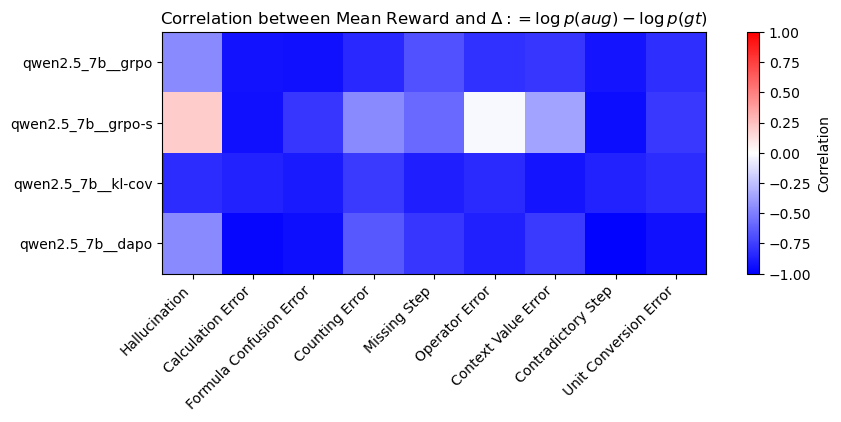

In [12]:
# Extract axes
methods = list(corrs.keys())
behaviors = list(next(iter(corrs.values())).keys())

# Build matrix
matrix = np.array([[corrs[m][b] for b in behaviors] for m in methods])

# Plot heatmap
plt.figure(figsize=(10, 4))
plt.imshow(matrix, cmap='bwr', vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(ticks=np.arange(len(behaviors)), labels=behaviors, rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(methods)), labels=methods)

plt.title("Correlation between Mean Reward and $\\Delta := \\log p(aug) - \\log p(gt)$")
plt.tight_layout()
plt.show()

In [26]:
def plot2(
    data: dict,
    behaviour_types : list[str],
    time_per_step_s: dict[str, int],
    suptitle_inject : str = ""
):

    methods = list(data.keys())
    n_methods = len(methods)
    n_behaviours = len(behaviour_types)

    ncols=int(np.sqrt(n_methods))
    nrows =int(np.ceil(n_methods / ncols))
    fig, axes = plt.subplots(
        figsize=(5 * ncols , 2 * nrows),
        ncols=ncols, nrows=nrows,
        squeeze=False, sharey=True
    )

    axes = axes.flatten()
    colors = plt.cm.tab10(np.linspace(0, 1, n_behaviours))
    markers = ['o', 's', '^', 'D', 'x', 'v', '+', '*']

    behaviours_per_method = { m : {b : [] for b in behaviour_types} for m in methods}
    ground_truths = {m : [] for m in methods}
    
    # precompute plotting y-values
    for method, checkpoints_data in data.items():
        for df in checkpoints_data:
            for name, group in df.groupby('behaviour_type'):
                behaviours_per_method[method][name].append(np.nanmean(group['behlp']))
    
    for ax, method in zip(axes, methods):
        for (beh, values), color, marker in zip(behaviours_per_method[method].items(), colors, markers):
            xs = np.arange(len(values)) * time_per_step_s[method]
            ax.plot(xs, values, label=beh, marker=marker, color=color)
        ax.set_title(method)

        x_seconds = np.arange(0, 90000, 20000)
        ax.set_xticks(x_seconds, [f"{int(h)}h" for h in (x_seconds // 3600)])
    
    fig.suptitle(f"$\\log p (aug)$. {suptitle_inject}", fontsize=18)
    plt.legend(bbox_to_anchor=(1, 1.04))
    plt.tight_layout()
    plt.show()

Path: /ptmp/rfechner/out/exp08/error_types__qwen2.5_7b__grpo, Dropped 51.39 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/error_types__qwen2.5_7b__grpo-s, Dropped 51.32 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/error_types__qwen2.5_7b__kl-cov, Dropped 51.31 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/error_types__qwen2.5_7b__dapo, Dropped 51.21 percent of rows on average.


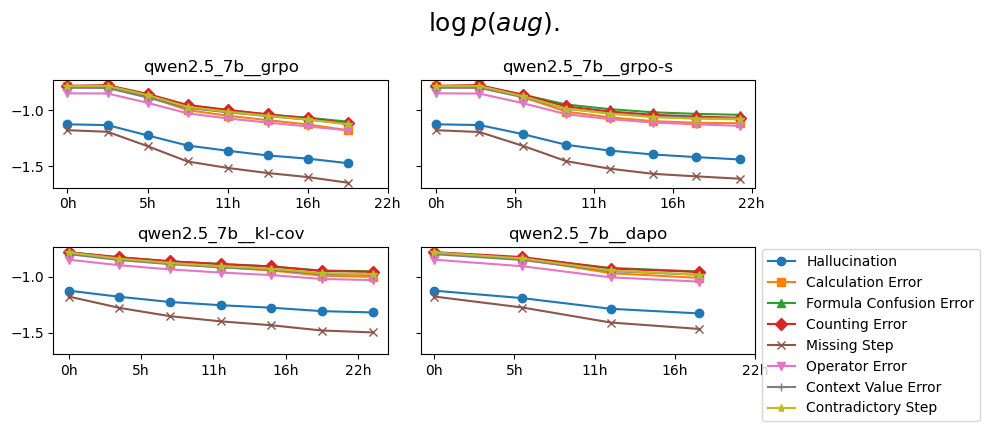

In [29]:
data, drop_p = load(paths=qwen_es_paths_abs, **parameters['All $\\log p(gt)$, Low $\\Delta$'])
plot2(data, data[list(data.keys())[0]][0]['behaviour_type'].unique(), time_per_step_s=timings_qwen)